# **Treinamento do modelo Transformer:**
<font size=3>

Aqui, iremos utilizar o [`MultiHeadAttention`](https://keras.io/api/layers/attention_layers/multi_head_attention/) do Keras, uma vez que já aprendemos como esta função é implementada.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

### **1. Importação e pré-processamento dos dados:**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/3-unidade/dataset/por-eng.csv")
print(df.shape)
df.head()

(196620, 2)


,por,eng
0,Vai.,Go.
1,Vá.,Go.
2,Oi.,Hi.
3,Corre!,Run!
4,Corra!,Run!


In [ ]:
# aplicando os tokens especiais para começo e parada da sentença em inglês
df["eng"] = df["eng"].apply(lambda x: "[start] " + x + " [end]")

# embaralhamento das amostras:
text_pairs = df.sample(frac=0.5).to_numpy() # AMOSTRAGEM REDUZIDA

print(text_pairs.shape)
text_pairs[0]

(98310, 2)


array(['Tom é muito magro.', '[start] Tom is too skinny. [end]'],
      dtype=object)

In [ ]:
# dividindo os dados entre treinamento, validação e teste:
n_samples = text_pairs.shape[0]

n_train = int(0.7*n_samples)
n_val = int(0.2*n_samples)

assert n_train + n_val < n_samples, "Proporção de separação inválida!"

train_pairs = text_pairs[:n_train]
val_pairs = text_pairs[n_train:n_train + n_val]
test_pairs = text_pairs[n_train + n_val:]

print(f"train:{train_pairs.shape}, val:{val_pairs.shape}, test:{test_pairs.shape}")

train:(68817, 2), val:(19662, 2), test:(9831, 2)


In [ ]:
import tensorflow as tf
from keras import layers

I0000 00:00:1781881413.806735   11274 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# hiperparâmetros:
vocab_eng_size = 5000
max_len = 16
embed_dim = 32
batch_size = 64
dense_dim = 128
num_heads = 4
n_layers = 3

def Preprocessor(x): # remove tudo que não for alfanumérico, exceto colchetes
    x = tf.strings.lower(x)
    return tf.strings.regex_replace(x, r"[^\w\s\[\]]", "")

# vetorização da fonte (português):
source_vec = layers.TextVectorization(max_tokens=vocab_eng_size,
                                      output_mode="int",
                                      output_sequence_length=max_len)

# vetorização do alvo (inglês):
target_vec = layers.TextVectorization(standardize=Preprocessor,
                                      max_tokens=vocab_eng_size,
                                      output_mode="int",
                                      output_sequence_length=max_len + 1) # "+1" para comportar a entrada do token "[start]"


# adaptando ao vocab_engulário de treino:
source_vec.adapt([pair[0] for pair in train_pairs])
target_vec.adapt([pair[1] for pair in train_pairs])

vocab_eng_por = source_vec.get_vocab_engulary()
vocab_eng_eng = target_vec.get_vocab_engulary()

for por, eng in zip(vocab_eng_por[:10], vocab_eng_eng[:10]):
    print(f"{por:^5} | {eng:^5}")


E0000 00:00:1781881415.533040   11274 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


      |      
[UNK] | [UNK]
 tom  | [start]
 que  | [end]
  o   |  tom 
 não  |   i  
 eu   |  to  
 de   |  you 
você  |  the 
  a   |   a  


In [ ]:
def format_dataset(por, eng):

    por = source_vec(por)
    eng = target_vec(eng)

    return ({"source": por,           # entrada do Encoder recebe Português
             "target": eng[:, :-1]},  # entrada Decoder recebe Inglês (sem o token [end])
            eng[:, 1:])               # o alvo é o Inglês deslocado (sem o token [start])

def make_dataset(pairs):

    por_texts, eng_texts = zip(*pairs)

    dataset = tf.data.Dataset.from_tensor_slices((list(por_texts), list(eng_texts)))

    dataset = dataset.batch(batch_size) # dividindo os dados em lotes (batches)
    dataset = dataset.map(format_dataset, num_parallel_calls=tf.data.AUTOTUNE) # paralelização do genador

    # cache: armazena todo o pré-processamento no disco para que, acada época, o gerador faça seu trabalho;
    # shuffle: embaralha os dados em janelas (buffers) de tamanho 2048 para melhor armazenamento de memória;
    # prefetch: equanto a GPU usa um lote para treinar, a CPU (em paralelo) prepara os próximos 16 lotes.
    return dataset.cache().shuffle(2048).prefetch(16)

train_dset = make_dataset(train_pairs)
val_dset   = make_dataset(val_pairs)
test_dset  = make_dataset(test_pairs)

example_batch = next(iter(train_dset))
inputs, targets = example_batch

print(f"Shape do Encoder Input (Português): {inputs['source'].shape}")
print(f"Shape do Decoder Input (Inglês):    {inputs['target'].shape}")
print(f"Shape do Label Real (Inglês):       {targets.shape}")

Shape do Encoder Input (Português): (64, 16)
Shape do Decoder Input (Inglês):    (64, 16)
Shape do Label Real (Inglês):       (64, 16)


In [ ]:
# apagando objetos desnecessários:
del df, text_pairs
del train_pairs, val_pairs, test_pairs

### **2. Vetorização:**

In [ ]:
class PositionalEmbedding(layers.Layer):

    def __init__(self, max_len, input_dim, output_dim):
        super().__init__()

        self.token_embeddings = layers.Embedding(input_dim=input_dim,
                                                 output_dim=output_dim)

        self.position_embeddings = layers.Embedding(input_dim=max_len,
                                                    output_dim=output_dim)

        self.max_len = max_len
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):

        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)

        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)

        return embedded_tokens + embedded_positions



### **3. Arquitetura Transformer:**

In [ ]:
import keras

In [ ]:
class EncoderLayer(layers.Layer):

    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()

        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim//num_heads)

        self.ffn = tf.keras.Sequential([layers.Dense(dense_dim, activation="gelu"),
                                        layers.Dense(embed_dim)])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, padding_mask=None):

        attn_output = self.mha(query=x, value=x, key=x, attention_mask=padding_mask)

        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)

        return x


class DecoderLayer(layers.Layer):

    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()

        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        self.mha1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim//num_heads)
        self.mha2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim//num_heads)

        self.ffn = tf.keras.Sequential([layers.Dense(dense_dim, activation="gelu"),
                                        layers.Dense(embed_dim)])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, y, x, padding_mask=None, causal_mask=None):

        attn1 = self.mha1(query=y, value=y, key=y, attention_mask=causal_mask)
        y = self.norm1(y + attn1)

        attn2 = self.mha2(query=y, value=x, key=x, attention_mask=padding_mask)
        y = self.norm2(y + attn2)

        ffn_output = self.ffn(y)
        y = self.norm3(y + ffn_output)

        return y


In [ ]:
class Transformer(keras.Model):

    def __init__(self, max_len, vocab_eng_size, embed_dim, dense_dim, num_heads, n_layers):
        super().__init__()

        self.encoder_embedding = PositionalEmbedding(max_len, vocab_eng_size, embed_dim)
        self.decoder_embedding = PositionalEmbedding(max_len, vocab_eng_size, embed_dim)

        self.encoder_block = [EncoderLayer(embed_dim, dense_dim, num_heads)
                              for _ in range(n_layers)]

        self.decoder_block = [DecoderLayer(embed_dim, dense_dim, num_heads)
                              for _ in range(n_layers)]

        self.output_layer = layers.Dense(vocab_eng_size, activation="softmax")


    def call(self, inputs):

        source = inputs["source"]
        target = inputs["target"]

        x, mask = self.encoder(source)

        return self.decoder(target, mask, x)


    def encoder(self, source):

        enc_padding_mask = self.padding_mask(source)

        x = self.encoder_embedding(source)

        for layer in self.encoder_block:
            x = layer(x, padding_mask=enc_padding_mask)

        return x, enc_padding_mask


    def decoder(self, target, enc_padding_mask, x):

        dec_padding_mask = self.padding_mask(target)
        causal_mask = self.causal_mask(tf.shape(target)[1])
        dec_combined_mask = tf.math.logical_and(dec_padding_mask, causal_mask)

        y = self.decoder_embedding(target)

        for layer in self.decoder_block:
            # padding mask para a entrada do português na atenção cruzada:
            y = layer(y, x, padding_mask=enc_padding_mask, causal_mask=dec_combined_mask)

        return self.output_layer(y)


    @staticmethod
    def padding_mask(seq):
        mask = tf.math.not_equal(seq, 0)
        return mask[:, tf.newaxis, tf.newaxis, :]


    @staticmethod
    def causal_mask(seq_len):
        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        return tf.cast(mask, tf.bool)[tf.newaxis, tf.newaxis, :, :]


### **4. Compilação do modelo:**

In [ ]:
from keras.optimizers import schedules
from keras import losses

In [ ]:
class CustomSchedule(schedules.LearningRateSchedule):

    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()

        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        arg1 = tf.math.rsqrt(step)
        arg2 = step*self.warmup_steps**-1.5

        return tf.math.rsqrt(self.d_model)*tf.math.minimum(arg1, arg2)


In [ ]:
def masked_loss(real, pred):

    real = tf.cast(real, tf.int64)

    loss = tf.keras.losses.sparse_categorical_crossentropy(real, pred)

    mask = tf.cast(tf.math.not_equal(real, 0), tf.float32)

    loss *= mask

    return tf.reduce_sum(loss)/tf.reduce_sum(mask)


In [ ]:
def masked_accuracy(real, pred):

    pred = tf.argmax(pred, axis=2)

    corrects = tf.equal(tf.cast(real, tf.int64), tf.cast(pred, tf.int64))

    mask = tf.math.not_equal(real, 0)

    # apenas consideramos acertos onde a máscara é True:
    corrects = tf.math.logical_and(corrects, mask)

    mask = tf.cast(mask, dtype=tf.float32)
    corrects = tf.cast(corrects, dtype=tf.float32)

    return tf.reduce_sum(corrects)/tf.reduce_sum(mask)


In [ ]:
model = Transformer(max_len, vocab_eng_size, embed_dim, dense_dim, num_heads, n_layers)

In [ ]:
# definindo o scheduler:
learning_rate = CustomSchedule(d_model=embed_dim)

# definindo o otimizador de acordo com o artigo:
optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# compilando:
model.compile(optimizer=optimizer, loss=masked_loss, metrics=[masked_accuracy])


### **5. Treinamento do modelo:**

In [ ]:
report = model.fit(train_dset, validation_data=val_dset, epochs=20)

Epoch 1/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 88s 73ms/step - loss: 5.9965 - masked_accuracy: 0.1903 - val_loss: 3.7710 - val_masked_accuracy: 0.3853
Epoch 2/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 77s 71ms/step - loss: 2.8596 - masked_accuracy: 0.5181 - val_loss: 2.1882 - val_masked_accuracy: 0.6122
Epoch 3/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 75s 70ms/step - loss: 1.9213 - masked_accuracy: 0.6558 - val_loss: 1.7671 - val_masked_accuracy: 0.6790
Epoch 4/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 76s 71ms/step - loss: 1.6274 - masked_accuracy: 0.6967 - val_loss: 1.6128 - val_masked_accuracy: 0.7028
Epoch 5/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 76s 70ms/step - loss: 1.4398 - masked_accuracy: 0.7246 - val_loss: 1.4900 - val_masked_accuracy: 0.7198
Epoch 6/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 78s 72ms/step - loss: 1.3034 - masked_accuracy: 0.7461 - val_loss: 1.4123 - val_masked_accuracy: 0.7341
Epoch 7/20
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 77s 72ms/step - loss: 1.2140 - masked_accuracy: 0.7598 - val_loss: 1.3825 - val_ma

In [ ]:
report.history.keys()

dict_keys(['loss', 'masked_accuracy', 'val_loss', 'val_masked_accuracy'])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

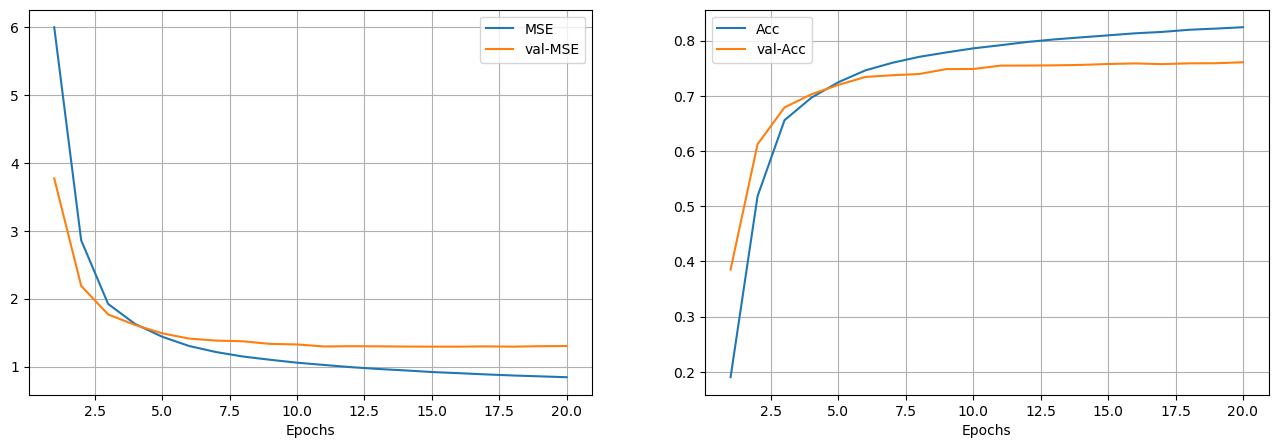

In [ ]:
loss = report.history['loss']
acc = report.history['masked_accuracy']

val_loss = report.history['val_loss']
val_acc = report.history['val_masked_accuracy']

epochs = np.linspace(1, len(loss), len(loss))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(epochs, loss, label='MSE')
ax[0].plot(epochs, val_loss, label='val-MSE')

ax[1].plot(epochs, acc, label='Acc')
ax[1].plot(epochs, val_acc, label='val-Acc')

for i in range(2):
    ax[i].set_xlabel("Epochs")
    ax[i].legend()
    ax[i].grid()

plt.show()

### **6. Avaliação:**

In [ ]:
loss, acc = model.evaluate(test_dset)
print(f"loss = {loss:.2f}, acc = {acc:.2f}")

154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 1.3332 - masked_accuracy: 0.7565
loss = 1.33, acc = 0.76


### **7. Exemplo de tradução:**

In [ ]:
def translater(sentence, model, tokenizer_pt, tokenizer_en):

    max_len = model.encoder_embedding.max_len

    sentence = tf.convert_to_tensor([sentence])
    encoder_input = tokenizer_pt(sentence)

    vocab_eng = tokenizer_en.get_vocabulary()

    start_index = vocab_eng.index('[start]')
    end_index = vocab_eng.index('[end]')

    # executando o encoder:
    x, enc_padding_mask = model.encoder(encoder_input)

    output_array = tf.constant([[start_index]], dtype=tf.int64)

    # loop autorregressivo do decoder:
    for i in range(max_len):
        predictions = model.decoder(output_array, enc_padding_mask, x)

        predictions = predictions[:, -1:, :] # seleciona o último token previsto
        predicted_id = tf.argmax(predictions, axis=-1)

        output_array = tf.concat([output_array, predicted_id], axis=-1)

        if int(predicted_id) == end_index:
            break

    # decodificação dos índices para strings:
    text_tokens = []
    for token in output_array[0]:
        word = vocab_eng[int(token)]
        if word not in ['[start]', '[end]', '', '[UNK]']:
            text_tokens.append(word)

    return " ".join(text_tokens)



In [ ]:
sentence = "eu gosto de ler livros"
translation = translater(sentence, model, source_vec, target_vec)

print(f"Original: {sentence}\n")
print(f"Tradução: {translation}")

Original: eu gosto de ler livros

Tradução: i like reading books
